# Data Extraction

In [56]:
import obspy, io
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import subprocess
import numpy as np

### Opening large mseed files
`obspy.read()` cannot directly read mini-SEED files that are larger than 2048 MB. Read the file in chunks instead ([link](https://github.com/obspy/obspy/pull/1419#issuecomment-221582369) to github issue).

Note on `record_len`: A record is a unit of data in the miniSEED format. A record consists of a certain number of data points in the waveform. Typical record lengths for raw data generation and archiving are between 256 and 4096 bytes ([FDSN docs](https://docs.fdsn.org/projects/miniseed3/en/latest/definition.html#:~:text=typical%20record%20lengths%20for%20raw%20data%20generation%20and%20archiving%20are%20recommended%20to%20be%20in%20the%20range%20of%20256%20and%204096%20bytes)).

In [117]:
# mseed_filename = "HE_020125_030125.mseed" # Queried from ISUH FDSNWS. It is a 3.7GB file containing waveforms from HE network from 2-3 Jan 2025
mseed_filename = "/home/ngdeqi/Documents/DATA11004 Project/eqdet/waveforms_directory/20251031T000000Z_20251031T010000Z/KLF/FN.KLF..BHE__20251031T000000Z__20251031T010000Z.mseed"
data_dir = Path("data")

record_len = 512
chunksize = 100000 * record_len
with io.open(data_dir / mseed_filename, "rb") as fh:
    while True:
        with io.BytesIO() as buf:
            c = fh.read(chunksize)
            if not c:
                break
            buf.write(c)
            buf.seek(0, 0)
            st = obspy.read(buf)
        # Do something useful!
        print(st)
        break # We just want to see the first stream from the mseed file

1 Trace(s) in Stream:
FN.KLF..BHE | 2025-10-31T00:00:00.000000Z - 2025-10-31T01:00:00.000000Z | 20.0 Hz, 72001 samples


### Querying waveform data from ISUH FDSNWS

To query ISUH FDSNWS dataselect service, ensure your device is connected to the university's network. Eduroam does not work, but wired connections on devices at the university do.

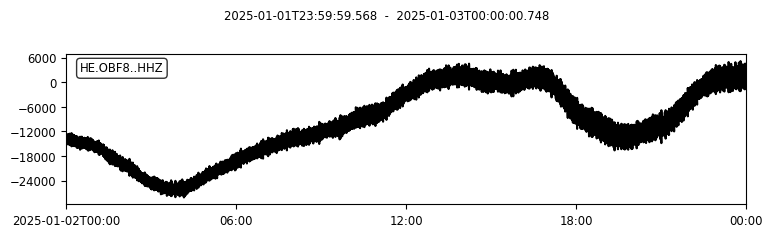

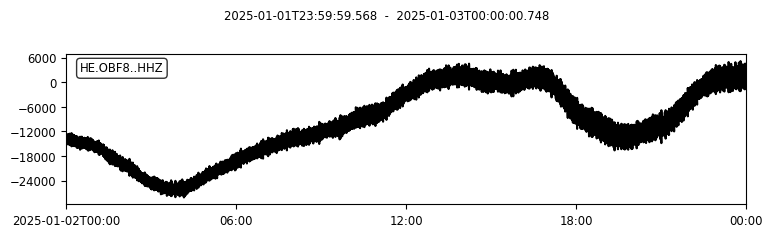

In [31]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime


client = Client("http://128.214.169.201:8080") # ISUH FDSNWS IP address

start_time = UTCDateTime("2025-01-01T23:59:59.568000Z")
end_time = UTCDateTime("2025-01-03T00:00:00.748000Z")

st = client.get_waveforms("HE", "OBF8", "*", "HHZ", start_time, end_time)

st.plot()

### Creating waveform dataset
1. Extract waveforms (containing P and S picks) from ISUH based on event quakeML 
2. Generate labels  

In [2]:
data_dir = Path("data")

paths = {
    "earthquakes": data_dir / "earthquakes2025.qkml",
    "explosions": data_dir / "explosions2025.qkml",
    "probable_explosions": data_dir / "probable_explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = obspy.read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

# Earthquake events catalog
eq_cat = catalogs["earthquakes"]

# Inspect a single event by index
i = 0
event = eq_cat[i]
print(event)

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml
probable_explosions: 1455 events loaded from probable_explosions2025.qkml
Event:	2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML

	            resource_id: ResourceIdentifier(id="smi:fi.isuh/event/1490639")
	             event_type: 'earthquake'
	    preferred_origin_id: ResourceIdentifier(id="smi:fi.isuh/origin/1490639")
	 preferred_magnitude_id: ResourceIdentifier(id="smi:fi.isuh/magnitude/1490639")
	                   ---------
	     event_descriptions: 1 Elements
	               comments: 3 Elements
	                  picks: 18 Elements
	             amplitudes: 3 Elements
	       focal_mechanisms: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements


In [23]:
event.resource_id.id

'smi:fi.isuh/event/1497264'

In [24]:
columns = ["Event id", "SEED string", "Pick type", "Event type", "Time"]
# Dataframe of all earthquake, explosion and probable_explosion picks
df_picks = pd.DataFrame(columns=columns)

# Store all pick information from all event catalogs into a dataframe
for catalog_name, catalog in catalogs.items():
    for event in catalog:
        for pick in event.picks:
            if pick.phase_hint and pick.phase_hint.startswith(("P", "S")):  # Only store S and P picks, avoid MSG picks
                event_id = event.resource_id.id                             # To uniquely identify a seismic event. An event can have multiple picks from multiple stations
                seed_string = pick.waveform_id.get_seed_string()            # SEED waveform string in the form network.station.location.channel, e.g. BW.FUR..EHZ
                # pick_type = pick.phase_hint[0]                              # Get first char, which is "P" or "S"
                pick_type = pick.phase_hint                                 # Get full phase hint

                event_type = catalog_name                                   # Earthquakes, explosions, or probable_explosions
                pick_time = pick.time                                       # Time of S or P pick, in UTC datetime format
                row_df = pd.DataFrame([[event_id, seed_string, pick_type, event_type, pick_time]], columns=columns)
                df_picks = pd.concat([df_picks, row_df], ignore_index=True)

In [25]:
df_picks.to_csv("picks.csv")
df_picks

,Event id,SEED string,Pick type,Event type,Time
0,smi:fi.isuh/event/1490639,UP.LANU..BHZ,P,earthquakes,2025-01-01T09:22:01.256470Z
1,smi:fi.isuh/event/1490639,UP.LANU..BHZ,S,earthquakes,2025-01-01T09:22:07.069410Z
2,smi:fi.isuh/event/1490639,HE.HEF..BHZ,P,earthquakes,2025-01-01T09:22:02.651570Z
3,smi:fi.isuh/event/1490639,HE.HEF..BHZ,S,earthquakes,2025-01-01T09:22:09.394590Z
4,smi:fi.isuh/event/1490639,FN.KLF..BHZ,P,earthquakes,2025-01-01T09:22:07.766970Z
...,...,...,...,...,...
54129,smi:fi.isuh/event/1497264,NO.ARA0..BHZ,Pg,probable_explosions,2025-02-28T23:55:18.650000Z
54130,smi:fi.isuh/event/1497264,NO.ARA0..BHZ,Sg,probable_explosions,2025-02-28T23:55:51.500000Z
54131,smi:fi.isuh/event/1497264,FN.RAJF..BHZ,Sb,probable_explosions,2025-02-28T23:56:07.360000Z
54132,smi:fi.isuh/event/1497264,HE.KEV..BHZ,Sg,probable_explosions,2025-02-28T23:56:10.880000Z


In [ ]:
df_picks_eq = df_picks[df_picks["Event type"] == "earthquakes"]

# Time of the earliest pick for a station for a given event, accommodating for station-events with only one pick
df_picks_eq["Event start"] = df_picks_eq.groupby(["Event id", df_picks_eq["SEED string"].str[:-3]])["Time"].transform("min")

# Time of the latest pick for a station for a given event, accommodating for station-events with only one pick
df_picks_eq["Event end"] = df_picks_eq.groupby(["Event id", df_picks_eq["SEED string"].str[:-3]])["Time"].transform("max")

max_diff = max(df_picks_eq["Event end"] - df_picks_eq["Event start"])
win_size = np.ceil(max_diff + 5 + 5)

print(f"Max duration between P and S wave: {max_diff}s")
print(f"Calculated waveform window query size: {win_size}s")

# Ensure that query window starts 5s before P wave
df_picks_eq["Start"] = df_picks_eq["Event start"] - 5 

# Ensure that query window ends at least win_size after P wave. 
df_picks_eq["End"] = df_picks_eq["Event end"].where(df_picks_eq["Event end"] - df_picks_eq["Start"] < win_size, 
                                                    df_picks_eq["Start"] + win_size)

# Ensure that S wave is still within the query window
assert (df_picks_eq["Event end"] - df_picks_eq["Start"] <= win_size).all(), "Query window is too short, S wave cut out!"

df_picks_eq.to_csv("earthquakes.csv")

Max duration between P and S wave: 86.70201s
Calculated waveform window query size: 97.0s


In [100]:
df_picks_eq["SEED string short"] = df_picks_eq["SEED string"].str[:-3]

df_stations_eq = df_picks_eq.drop_duplicates(["Event id", "SEED string short"])

for seed_string, start, end in zip(df_stations_eq["SEED string short"], df_stations_eq["Start"], df_stations_eq["End"]):
    print(seed_string)
    cmd = ["python", "create_dataset.py", 
                    "--start", str(start), "--end", str(end), 
                    "--streams", seed_string,
                    "--host", "http://128.214.169.201:8080",
                    "--output", "waveforms_directory",
                    "--chunk", str(int(np.ceil(win_size/60)))]
    subprocess.run(cmd)

UP.LANU..
Total time: 2025-01-01T09:21:56.256470Z → 2025-01-01T09:22:07.069410Z  (10.81294 s)
Chunk size: 2 minute(s) → 1 window(s)


=== WINDOW 1/1: 20250101T092156Z → 20250101T092207Z ===
  Fetching for: UP.LANU.*.*
HTTP Status code: 204
Detailed response of server:


  No data downloaded for this window.

All windows processed. Done.
HE.HEF..
Total time: 2025-01-01T09:21:57.651570Z → 2025-01-01T09:22:09.394590Z  (11.74302 s)
Chunk size: 2 minute(s) → 1 window(s)


=== WINDOW 1/1: 20250101T092157Z → 20250101T092209Z ===
  Fetching for: HE.HEF.*.*
  Wrote /home/ad/lxhome/n/ngdeqi/Linux/Documents/DATA11004 Project/eqdet/waveforms_directory/20250101T092157Z_20250101T092209Z/HEF/HE.HEF..HHE__20250101T092157Z__20250101T092209Z.mseed  (1 traces)
  Wrote /home/ad/lxhome/n/ngdeqi/Linux/Documents/DATA11004 Project/eqdet/waveforms_directory/20250101T092157Z_20250101T092209Z/HEF/HE.HEF..HHN__20250101T092157Z__20250101T092209Z.mseed  (1 traces)
  Wrote /home/ad/lxhome/n/ngdeqi/Linux/Documents/DA

Traceback (most recent call last):
  File "/home/ad/lxhome/n/ngdeqi/Linux/Documents/DATA11004 Project/eqdet/create_dataset.py", line 7, in <module>
    from obspy.clients.fdsn import Client
  File "/home/ngdeqi/Documents/DATA11004 Project/eqdet/.venv/lib/python3.12/site-packages/obspy/clients/fdsn/__init__.py", line 246, in <module>
    from .routing.routing_client import RoutingClient  # NOQA
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ngdeqi/Documents/DATA11004 Project/eqdet/.venv/lib/python3.12/site-packages/obspy/clients/fdsn/routing/routing_client.py", line 25, in <module>
    from ...base import HTTPClient
  File "/home/ngdeqi/Documents/DATA11004 Project/eqdet/.venv/lib/python3.12/site-packages/obspy/clients/base.py", line 55, in <module>
    import requests
  File "/home/ngdeqi/Documents/DATA11004 Project/eqdet/.venv/lib/python3.12/site-packages/requests/__init__.py", line 43, in <module>
    import urllib3
  File "/home/ngdeqi/Documents/DATA11004 Project

KeyboardInterrupt: 